In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Настройки для красивого отображения графиков
sns.set_theme(style="whitegrid")

# 1. Загрузка данных
# Указываем index_col=0, чтобы первая колонка (просто порядковые номера) стала индексом
df = pd.read_csv('cs-training.csv', index_col=0) 

# 2. Смотрим на первые 5 строк глазами
print("--- Первые 5 строк датасета ---")
display(df.head())

# 3. Смотрим общую информацию (типы данных, количество непустых значений)
print("\n--- Общая информация ---")
df.info()

# 4. Базовая статистика (минимум, максимум, среднее)
# Транспонируем (.T) для удобного чтения
print("\n--- Базовая статистика ---")
display(df.describe().T)

--- Первые 5 строк датасета ---


,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
1,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
2,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
3,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
4,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
5,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0



--- Общая информация ---
<class 'pandas.core.frame.DataFrame'>
Index: 150000 entries, 1 to 150000
Data columns (total 11 columns):
 #   Column                                Non-Null Count   Dtype  
---  ------                                --------------   -----  
 0   SeriousDlqin2yrs                      150000 non-null  int64  
 1   RevolvingUtilizationOfUnsecuredLines  150000 non-null  float64
 2   age                                   150000 non-null  int64  
 3   NumberOfTime30-59DaysPastDueNotWorse  150000 non-null  int64  
 4   DebtRatio                             150000 non-null  float64
 5   MonthlyIncome                         120269 non-null  float64
 6   NumberOfOpenCreditLinesAndLoans       150000 non-null  int64  
 7   NumberOfTimes90DaysLate               150000 non-null  int64  
 8   NumberRealEstateLoansOrLines          150000 non-null  int64  
 9   NumberOfTime60-89DaysPastDueNotWorse  150000 non-null  int64  
 10  NumberOfDependents                    146076 no

,count,mean,std,min,25%,50%,75%,max
SeriousDlqin2yrs,150000.0,0.066840,0.249746,0.0,0.000000,0.000000,0.000000,1.0
RevolvingUtilizationOfUnsecuredLines,150000.0,6.048438,249.755371,0.0,0.029867,0.154181,0.559046,50708.0
age,150000.0,52.295207,14.771866,0.0,41.000000,52.000000,63.000000,109.0
NumberOfTime30-59DaysPastDueNotWorse,150000.0,0.421033,4.192781,0.0,0.000000,0.000000,0.000000,98.0
DebtRatio,150000.0,353.005076,2037.818523,0.0,0.175074,0.366508,0.868254,329664.0
MonthlyIncome,120269.0,6670.221237,14384.674215,0.0,3400.000000,5400.000000,8249.000000,3008750.0
NumberOfOpenCreditLinesAndLoans,150000.0,8.452760,5.145951,0.0,5.000000,8.000000,11.000000,58.0
NumberOfTimes90DaysLate,150000.0,0.265973,4.169304,0.0,0.000000,0.000000,0.000000,98.0
NumberRealEstateLoansOrLines,150000.0,1.018240,1.129771,0.0,0.000000,1.000000,2.000000,54.0
NumberOfTime60-89DaysPastDueNotWorse,150000.0,0.240387,4.155179,0.0,0.000000,0.000000,0.000000,98.0


C:\Users\yrysd\AppData\Local\Temp\ipykernel_15220\3873129628.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df, x='SeriousDlqin2yrs', palette='Set2')


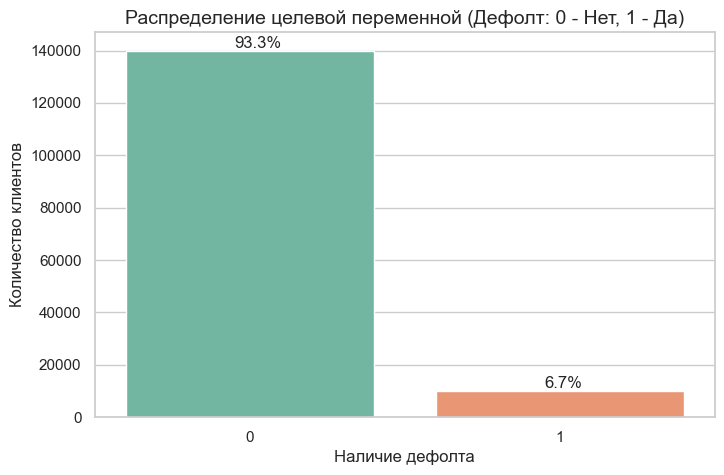

In [2]:
# Настраиваем размер графика
plt.figure(figsize=(8, 5))

# Строим график распределения целевой переменной
ax = sns.countplot(data=df, x='SeriousDlqin2yrs', palette='Set2')

# Добавляем подписи
plt.title('Распределение целевой переменной (Дефолт: 0 - Нет, 1 - Да)', fontsize=14)
plt.xlabel('Наличие дефолта', fontsize=12)
plt.ylabel('Количество клиентов', fontsize=12)

# Добавляем проценты над столбиками для наглядности
total = len(df)
for p in ax.patches:
    percentage = f'{100 * p.get_height() / total:.1f}%'
    x = p.get_x() + p.get_width() / 2 - 0.05
    y = p.get_y() + p.get_height() + 1000
    ax.annotate(percentage, (x, y), size=12)

plt.show()

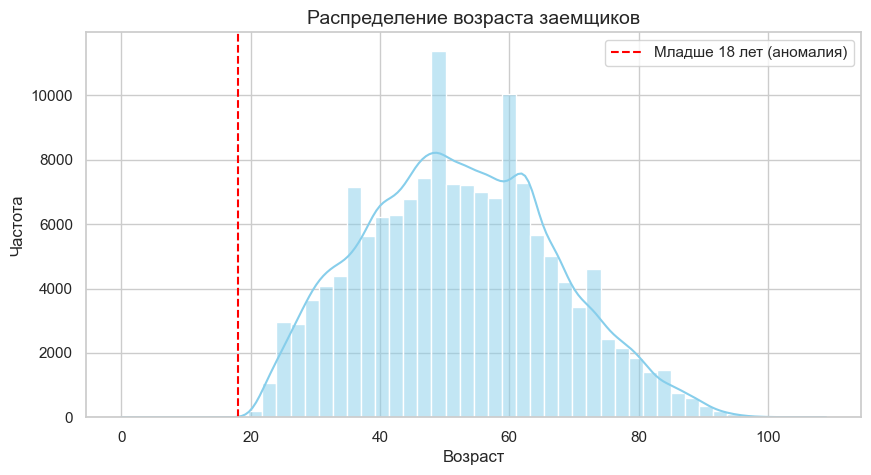

In [4]:
plt.figure(figsize=(10, 5))

# Строим гистограмму возраста с шагом в 2 года
sns.histplot(df['age'], bins=50, kde=True, color='skyblue')

plt.title('Распределение возраста заемщиков', fontsize=14)
plt.xlabel('Возраст', fontsize=12)
plt.ylabel('Частота', fontsize=12)

# Отметим красной линией границу совершеннолетия (например, 18 лет)
plt.axvline(18, color='red', linestyle='--', label='Младше 18 лет (аномалия)')
plt.legend()

plt.show()

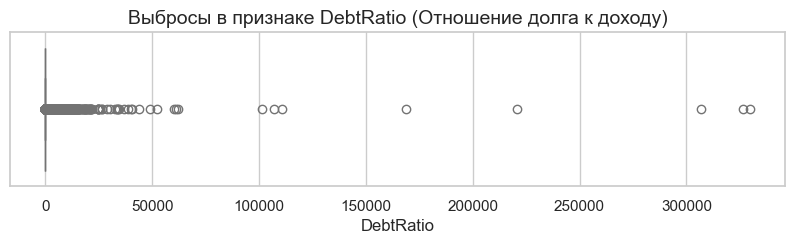

In [5]:
plt.figure(figsize=(10, 2))

# Строим горизонтальный boxplot
sns.boxplot(x=df['DebtRatio'], color='lightgreen')

plt.title('Выбросы в признаке DebtRatio (Отношение долга к доходу)', fontsize=14)
plt.xlabel('DebtRatio', fontsize=12)

plt.show()

In [6]:
# Создаем копию датасета для экспериментов, чтобы не испортить оригинал
df_clean = df.copy()

# --- 1. Чиним возраст (Младенцы) ---
# Находим медианный возраст (он устойчив к выбросам)
median_age = df_clean['age'].median()
# Заменяем все значения меньше 18 на медиану
df_clean.loc[df_clean['age'] < 18, 'age'] = median_age

# --- 2. Чиним иждивенцев (NumberOfDependents) ---
# Если человек не указал количество иждивенцев, логично предположить, что их нет (0).
df_clean['NumberOfDependents'] = df_clean['NumberOfDependents'].fillna(0)

# --- 3. Чиним доход (MonthlyIncome) ---
# 30 000 пропусков — это много. Заполним их медианным доходом.
median_income = df_clean['MonthlyIncome'].median()
df_clean['MonthlyIncome'] = df_clean['MonthlyIncome'].fillna(median_income)

# --- 4. Укрощаем выбросы в DebtRatio ---
# Используем метод "Винзоризация" (обрезание хвостов). 
# Все, что выше 95-го перцентиля (самые экстремальные 5%), мы приравняем к этому 95-му перцентилю.
debt_ratio_95 = df_clean['DebtRatio'].quantile(0.95)
df_clean.loc[df_clean['DebtRatio'] > debt_ratio_95, 'DebtRatio'] = debt_ratio_95

# --- 5. Укрощаем выбросы в лимитах (RevolvingUtilizationOfUnsecuredLines) ---
# Аналогично обрезаем сумасшедшие проценты использования кредитки
rev_util_95 = df_clean['RevolvingUtilizationOfUnsecuredLines'].quantile(0.95)
df_clean.loc[df_clean['RevolvingUtilizationOfUnsecuredLines'] > rev_util_95, 'RevolvingUtilizationOfUnsecuredLines'] = rev_util_95

# Проверяем результат: остались ли пустые значения?
print("--- Осталось пустых значений ---")
print(df_clean.isnull().sum())

--- Осталось пустых значений ---
SeriousDlqin2yrs                        0
RevolvingUtilizationOfUnsecuredLines    0
age                                     0
NumberOfTime30-59DaysPastDueNotWorse    0
DebtRatio                               0
MonthlyIncome                           0
NumberOfOpenCreditLinesAndLoans         0
NumberOfTimes90DaysLate                 0
NumberRealEstateLoansOrLines            0
NumberOfTime60-89DaysPastDueNotWorse    0
NumberOfDependents                      0
dtype: int64


In [7]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, classification_report

# 1. Отделяем целевую переменную (y - дефолт) от признаков (X - все остальное)
X = df_clean.drop('SeriousDlqin2yrs', axis=1)
y = df_clean['SeriousDlqin2yrs']

# 2. Разбиваем данные на обучение (80%) и тест (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 3. Масштабирование данных
# Обучаем скалер ТОЛЬКО на train, а потом применяем к train и test
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 4. Обучение базовой модели
# Указываем class_weight='balanced' из-за дисбаланса классов
log_reg = LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000)
log_reg.fit(X_train_scaled, y_train)

# 5. Предсказания
# Для ROC-AUC нам нужны вероятности (probability) дефолта, а не просто 0 или 1
y_pred_proba = log_reg.predict_proba(X_test_scaled)[:, 1] 
y_pred = log_reg.predict(X_test_scaled) # Обычные классы для отчета

# 6. Оценка качества
roc_auc = roc_auc_score(y_test, y_pred_proba)

print("--- Результаты Логистической Регрессии ---")
print(f"ROC-AUC Score: {roc_auc:.4f}\n")
print("Classification Report:")
print(classification_report(y_test, y_pred))

--- Результаты Логистической Регрессии ---
ROC-AUC Score: 0.8339

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.76      0.86     27995
           1       0.18      0.75      0.29      2005

    accuracy                           0.76     30000
   macro avg       0.58      0.75      0.57     30000
weighted avg       0.92      0.76      0.82     30000



In [8]:
pip install xgboost

   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.3/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.3/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.3/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.3/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.3/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.3/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.8/101.7 MB 459.0 kB/s eta 0:03:40
   ---------------------------------------- 0.8/101.7 MB 459.0 kB/s eta 0:03:40
   ---------------------------------------- 1.0/101.7 MB 532.6 kB/s eta 0:03:09
    --------------------------------------- 1.3/101.7 MB 590.1 kB/s eta 0:02:51
    -------------------------------------

Отношение хороших клиентов к плохим (scale_pos_weight): 13.96

--- Результаты XGBoost ---
ROC-AUC Score: 0.8685

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.79      0.88     27995
           1       0.21      0.78      0.34      2005

    accuracy                           0.79     30000
   macro avg       0.60      0.79      0.61     30000
weighted avg       0.93      0.79      0.84     30000



<Figure size 1000x600 with 0 Axes>

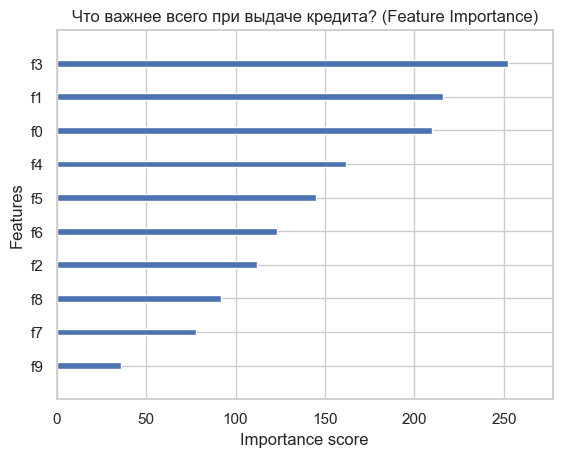

In [ ]:
from xgboost import XGBClassifier
import xgboost as xgb

# 1. Считаем баланс классов для параметра scale_pos_weight
# Считаем сколько нулей (хороших) и единиц (дефолтов) в тренировочной выборке
ratio = float(np.sum(y_train == 0)) / np.sum(y_train == 1)
print(f"Отношение хороших клиентов к плохим (scale_pos_weight): {ratio:.2f}\n")

# 2. Обучаем XGBoost
# Обрати внимание: мы можем использовать не масштабированные данные (X_train), 
# деревьям не нужен StandardScaler, но для удобства возьмем уже готовые X_train_scaled.
xgb_model = XGBClassifier(
    scale_pos_weight=ratio, 
    random_state=42, 
    eval_metric='auc', # Сразу просим его ориентироваться на ROC-AUC
    max_depth=4,       # Глубина дерева (чтобы не переобучился)
    learning_rate=0.1, # Шаг обучения
    n_estimators=100   # Количество деревьев
)

xgb_model.fit(X_train_scaled, y_train)

# 3. Предсказания
xgb_pred_proba = xgb_model.predict_proba(X_test_scaled)[:, 1]
xgb_pred = xgb_model.predict(X_test_scaled)

# 4. Оценка
xgb_roc_auc = roc_auc_score(y_test, xgb_pred_proba)

print("--- Результаты XGBoost ---")
print(f"ROC-AUC Score: {xgb_roc_auc:.4f}\n")
print("Classification Report:")
print(classification_report(y_test, xgb_pred))

# 5.  Важность признаков (Feature Importance)
plt.figure(figsize=(10, 6))
# Строим график того, на что модель смотрит в первую очередь
xgb.plot_importance(xgb_model, max_num_features=10, importance_type='weight', show_values=False)
plt.title('Что важнее всего при выдаче кредита? (Feature Importance)')
plt.show()

<Figure size 1000x600 with 0 Axes>

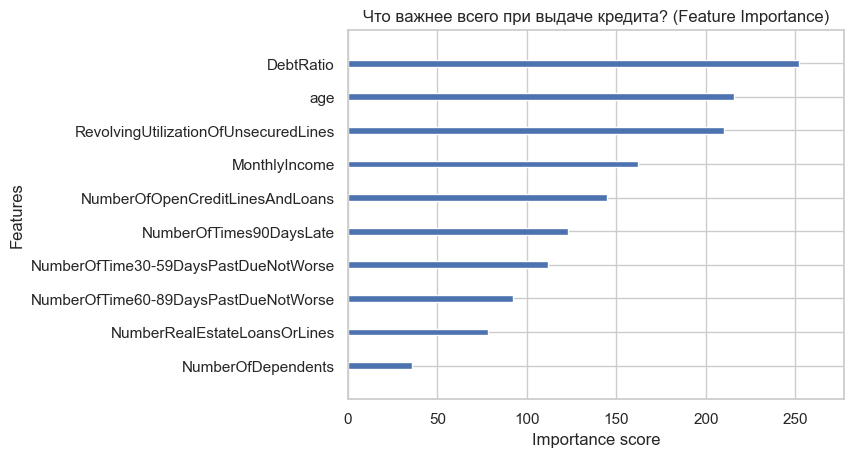

In [10]:
# Возвращаем имена колонок в модель
xgb_model.get_booster().feature_names = list(X.columns)

# Снова строим красивый график
plt.figure(figsize=(10, 6))
xgb.plot_importance(xgb_model, max_num_features=10, importance_type='weight', show_values=False)
plt.title('Что важнее всего при выдаче кредита? (Feature Importance)')
plt.show()

In [ ]:
from sklearn.model_selection import GridSearchCV
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score

# 1. Задаем сетку параметров (то, что будем перебирать)
# Мы пробуем разную глубину деревьев, разный шаг обучения и разное количество деревьев
param_grid = {
    'max_depth': [3, 4, 5],
    'learning_rate': [0.05, 0.1, 0.2],
    'n_estimators': [100, 200]
}

# 2. Создаем "пустую" модель (оставляем только балансировку классов)
# ratio - это переменная из прошлого шага (около 13.96)
xgb_base = XGBClassifier(
    scale_pos_weight=ratio, 
    random_state=42, 
    eval_metric='auc'
)

# 3. Настраиваем GridSearch с кросс-валидацией (cv=3)
# Он проверит 3 * 3 * 2 = 18 комбинаций. 
# Каждую обучит 3 раза (CV=3). Итого: 54 обучения модели!
grid_search = GridSearchCV(
    estimator=xgb_base,
    param_grid=param_grid,
    scoring='roc_auc', # Оптимизируем именно по нашей главной метрике
    cv=3,              # Данные разбиваются на 3 части для кросс-валидации
    verbose=2,         # Будет печатать прогресс в консоль, чтобы не было скучно
    n_jobs=-1          # Используем все ядра процессора
)

# 4. Запускаем перебор на тренировочных данных
print("Начинаем подбор параметров.")
grid_search.fit(X_train_scaled, y_train)

# 5. Выводим результаты
print("\n--- Результаты GridSearch ---")
print(f"Лучшие параметры: {grid_search.best_params_}")
print(f"Лучший ROC-AUC на кросс-валидации: {grid_search.best_score_:.4f}")

# 6. Достаем самую лучшую модель
best_xgb_model = grid_search.best_estimator_

# 7. Финальная проверка на тестовой выборке (test set), которую модель еще не видела!
best_xgb_pred_proba = best_xgb_model.predict_proba(X_test_scaled)[:, 1]
final_roc_auc = roc_auc_score(y_test, best_xgb_pred_proba)

print(f"Итоговый ROC-AUC на отложенном тесте: {final_roc_auc:.4f}")

Начинаем подбор параметров. Идем за кофе... ☕
Fitting 3 folds for each of 18 candidates, totalling 54 fits

--- Результаты GridSearch ---
Лучшие параметры: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 200}
Лучший ROC-AUC на кросс-валидации: 0.8634
Итоговый ROC-AUC на отложенном тесте: 0.8684


In [13]:
import joblib

# Сохраняем модель XGBoost
joblib.dump(xgb_model, 'xgb_scoring_model.pkl')

# Сохраняем Scaler
joblib.dump(scaler, 'scaler.pkl')

print("Модель и скейлер успешно сохранены!")

Модель и скейлер успешно сохранены!
